**Dataset Loading** means downloading and loading an image dataset so that our CNN model can use it for training and testing.

For this notebook, we will start with **Fashion-MNIST**.

Fashion-MNIST contains images of clothing items such as shirts, shoes, trousers, bags, etc. Each image is a **28 × 28 grayscale image** and belongs to one of **10 classes**.

We need to load two datasets:

- **Training dataset** → used to train the CNN.
- **Test dataset** → used to evaluate the trained CNN on unseen images.

We use `torchvision.datasets.FashionMNIST()` to load the dataset.

`download=True` means PyTorch will download the dataset automatically if it is not already available on the computer.

**Why do we need dataset loading?**

Before building and training a CNN, we need image data. Dataset loading gives us the images and their corresponding class labels in a format that PyTorch can work with.

**Real-world example:**  
For a clothes classification system, thousands of clothing images would be loaded first. The CNN would then learn to identify whether an image is a shirt, shoe, bag, trouser, etc.

In [1]:

import torch
from torchvision import datasets
from torchvision.transforms import ToTensor

# Load training dataset
train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# Load test dataset
test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))


100%|██████████| 26.4M/26.4M [00:07<00:00, 3.57MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 128kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.04MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 1.36MB/s]

Training images: 60000
Test images: 10000


**Dataset inspection** means checking the basic information about our dataset before training the CNN.

We should check:

- Number of images
- Image shape
- Label
- Data type
- Pixel value range

For Fashion-MNIST, each image is **28 × 28 pixels** and is grayscale, so it has only **1 channel**.

After applying `ToTensor()`, the image is represented as a PyTorch tensor with the shape:

`[1, 28, 28]`

Here:

- `1` → grayscale channel
- `28` → image height
- `28` → image width

We inspect the dataset because it helps us understand what data we are giving to the CNN and verify that the data has been loaded correctly.

**Real-world example:**  
Before training a system to identify defective products, we would first check how many images we have, their image sizes, labels, and whether the images are in the expected format.

In [2]:

# Get one image and its label
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())


Image shape: torch.Size([1, 28, 28])
Label: 9
Data type: torch.float32
Minimum pixel value: tensor(0.)
Maximum pixel value: tensor(1.)


**Class analysis** means checking what classes are present in the dataset and how many images belong to each class.

Fashion-MNIST has **10 classes**:

- `0` → T-shirt/top
- `1` → Trouser
- `2` → Pullover
- `3` → Dress
- `4` → Coat
- `5` → Sandal
- `6` → Shirt
- `7` → Sneaker
- `8` → Bag
- `9` → Ankle boot

We check the number of images in each class to understand whether the dataset is reasonably balanced.

For a classification problem, class analysis is important because if one class has far fewer images than the others, the model may learn that class poorly.

**Real-world example:**  
If a company has 10 types of products but has 9,000 images for one product and only 500 images for another, the model may perform much better on the product with more training images.

In [3]:

from collections import Counter

# Get all labels
labels = [label for _, label in train_dataset]

# Count images in each class
class_counts = Counter(labels)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for class_id, count in sorted(class_counts.items()):
    print(class_id, class_names[class_id], ":", count)


0 T-shirt/top : 6000
1 Trouser : 6000
2 Pullover : 6000
3 Dress : 6000
4 Coat : 6000
5 Sandal : 6000
6 Shirt : 6000
7 Sneaker : 6000
8 Bag : 6000
9 Ankle boot : 6000


**Image visualization** means displaying some images from the dataset so that we can see what the actual input looks like.

Before training a CNN, it is useful to visually inspect the images and their labels.

For Fashion-MNIST, the images are small **28 × 28 grayscale images**. We can display a few images along with their class names.

This helps us verify:

- The images were loaded correctly.
- The images are visually meaningful.
- The labels match the images.
- The image format is suitable for CNN training.

**Real-world example:**  
Before training a model to identify defective products, we would look at some sample images to make sure the images are not corrupted and the labels are correct.

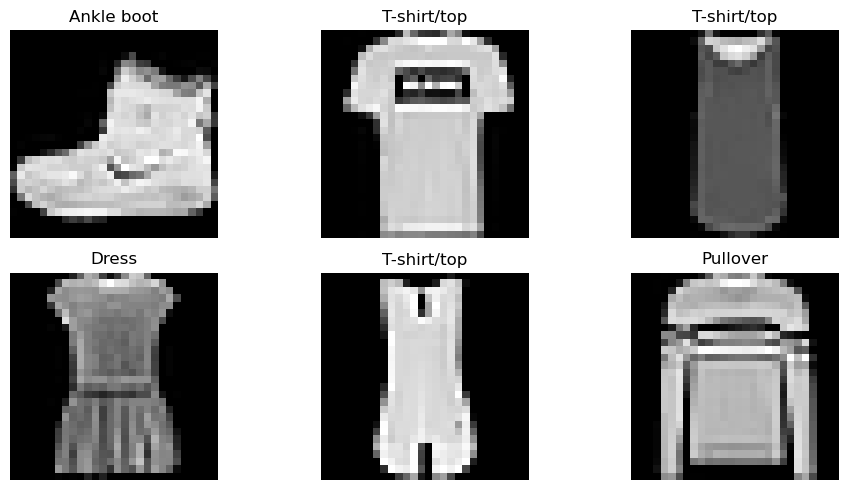

In [5]:

import matplotlib.pyplot as plt

# Display 6 images
plt.figure(figsize=(10, 5))

for i in range(6):
    image, label = train_dataset[i]

    plt.subplot(2, 3, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


**Preprocessing** means preparing images so they are in a suitable format for the CNN.

For our Fashion-MNIST dataset, we will use `ToTensor()`.

`ToTensor()` performs two important things:

- Converts the image into a PyTorch tensor.
- Converts pixel values from **0–255** to **0–1**.

For example:

```text
Original pixel → 255
Tensor pixel   → 1.0
```

This makes the image data easier for the neural network to work with.

The image shape remains:

```text
[1, 28, 28]
```

where `1` is the grayscale channel.

**Why do we need preprocessing?**

Raw image data is not always in the format expected by a CNN. Preprocessing converts the images into a consistent numerical format that PyTorch and the CNN can use.

**Real-world example:**  
Before giving photographs to a face-recognition model, images may be resized and converted into tensors so that every image has the expected format.

In [6]:

from torchvision import transforms

# Define preprocessing
preprocess = transforms.ToTensor()

# Load dataset with preprocessing
train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=preprocess
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=preprocess
)

# Check one image
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Minimum value:", image.min())
print("Maximum value:", image.max())

Image shape: torch.Size([1, 28, 28])
Minimum value: tensor(0.)
Maximum value: tensor(1.)


**Data augmentation** means creating slightly modified versions of training images so that the CNN sees more variations of the same type of image.

For Fashion-MNIST, we can use simple augmentation such as:

- **RandomHorizontalFlip** → randomly flips the image horizontally.
- **RandomRotation** → slightly rotates the image.

Augmentation is applied to the **training dataset**, not normally to the test dataset.

**Why do we need augmentation?**

It helps the CNN learn that small changes in an image should not change its class.

For example, a shoe may be slightly rotated or positioned differently, but it is still a shoe.

**Important:** We should use augmentation only when the transformation makes sense for the image. For example, flipping some objects horizontally may be acceptable, while flipping text may change its meaning.

**Real-world example:**  
If we have 1,000 shoe images, we can slightly rotate or flip some training images to create more variations for the model to learn from.

In [7]:

from torchvision import transforms

# Preprocessing + augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# Test dataset: only preprocessing
test_transform = transforms.Compose([
    transforms.ToTensor()
])

# Training dataset
train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

# Test dataset
test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)

print("Augmentation applied to training dataset.")
print("Only preprocessing applied to test dataset.")


Augmentation applied to training dataset.
Only preprocessing applied to test dataset.


**DataLoader** is used to load images from the dataset in small groups called **batches**.

Instead of giving all 60,000 training images to the CNN at once, we can divide them into batches.

For example, with:

`batch_size = 64`

the CNN receives **64 images at a time**.

We usually use:

- `shuffle=True` for training → randomly changes the order of images.
- `shuffle=False` for testing → keeps the test data order unchanged.

**Why do we need DataLoader?**

It makes training easier and more efficient because the model can process a manageable number of images at a time.

**Real-world example:**  
Instead of giving 60,000 documents to an employee at once, we can give them 64 documents at a time and continue until all documents are processed.

In [8]:

from torch.utils.data import DataLoader

# Create training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# Create test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Check one batch
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)


Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


A **CNN (Convolutional Neural Network)** is designed to learn useful features from images.

For our Fashion-MNIST classification model, we will use a simple CNN architecture:

**Input → Convolution → ReLU → Pooling → Convolution → ReLU → Pooling → Flatten → Fully Connected → Output**

### Layers we use

- **Conv2d** → detects image features such as edges and shapes.
- **ReLU** → adds non-linearity so the network can learn complex patterns.
- **MaxPool2d** → reduces the image size while keeping important features.
- **Flatten** → converts the feature maps into a one-dimensional vector.
- **Linear** → performs classification using the learned features.
- **Output layer** → produces 10 outputs because Fashion-MNIST has 10 classes.

The final output contains **10 values**, one for each Fashion-MNIST class.

**Real-world example:**  
For clothing classification, early CNN layers may learn simple patterns such as edges. Deeper layers can combine these patterns to recognize shapes associated with shoes, shirts, bags, etc.

In [10]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # First convolution block
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Second convolution block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Flatten
            nn.Flatten(),

            # Fully connected layers
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)


# Create model
model = CNN()

print(model)


CNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


**Training** means teaching the CNN to recognize different types of clothing images.

During training:

1. A batch of images is given to the CNN.
2. The CNN makes predictions.
3. The predictions are compared with the correct labels using a **loss function**.
4. The model calculates gradients using backpropagation.
5. The optimizer updates the model's weights.
6. This process repeats for many batches.

We will use:

- **CrossEntropyLoss** → calculates classification loss.
- **Adam optimizer** → updates the model weights.
- **Epoch** → one complete pass through the training dataset.

For example, with `epochs=5`, the model will see the complete training dataset five times.

**Real-world example:**  
Teaching a person to identify different types of clothes involves showing examples, checking their answers, correcting mistakes, and repeating the process. CNN training works in a similar way.

In [11]:

import torch
import torch.nn as nn
import torch.optim as optim

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = CNN().to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {average_loss:.4f}"
    )


Epoch [1/5], Loss: 0.5308



KeyboardInterrupt



**Validation** means checking how well the CNN performs on data that was **not used to update the model's weights during training**.

Validation helps us understand whether the model is learning useful patterns or simply memorizing the training images.

During validation:

- We do **not** update model weights.
- We calculate the validation loss.
- We calculate validation accuracy.
- We use `model.eval()` to put the model into evaluation mode.
- We use `torch.no_grad()` because gradients are not required.

A good model should have good performance on both training and validation data.

**Real-world example:**  
A student studies using practice questions and then takes a separate practice test. The practice test helps determine whether the student actually learned the topic instead of simply memorizing the practice questions.
### Important note
Our current notebook has only a training dataset and test dataset. For proper validation, we should split part of the training dataset into a validation dataset.

In [12]:

from torch.utils.data import random_split

# Split training dataset into training and validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Training images:", len(train_data))
print("Validation images:", len(val_data))


Training images: 48000
Validation images: 12000


In [14]:

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)


In [15]:

model.eval()

correct = 0
total = 0
val_loss = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total
average_val_loss = val_loss / len(val_loader)

print("Validation Loss:", round(average_val_loss, 4))
print("Validation Accuracy:", round(val_accuracy, 2), "%")


Validation Loss: 0.3593
Validation Accuracy: 86.8 %


The exact result will vary.
Training → learn the weights
Validation → check the model while developing it
Testing → final evaluation on unseen data

**Testing** means evaluating the final CNN model on the **test dataset**, which the model has not used for training or validation.

Testing tells us how well the trained model can classify completely unseen images.

During testing:

- We use `model.eval()`.
- We do not update the model weights.
- We use `torch.no_grad()`.
- We calculate the final **test accuracy**.

The test dataset contains **10,000 Fashion-MNIST images**.

**Why do we need testing?**

Training accuracy tells us how well the model learned the training data. Validation helps us monitor the model during development. Testing gives us the final performance of the selected model on unseen data.

**Real-world example:**  
After training a system to identify different clothing products, we give it new product images that it has never seen before. Its accuracy on these images tells us how well it works in the real world.

Training data → augmentation

Validation data → no augmentation

Test data → no augmentation

In [16]:

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Predictions
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", round(test_accuracy, 2), "%")


Test Accuracy: 87.04 %


**Error analysis** means finding and studying the images that the CNN classified incorrectly.

Accuracy tells us **how many predictions are correct**, but it does not tell us **what kinds of mistakes the model is making**.

For example, the model may correctly identify most shoes but frequently confuse:

- Shirt ↔ T-shirt/top
- Coat ↔ Pullover
- Sandal ↔ Sneaker

We can display incorrectly classified images and compare:

- **Actual class** → correct label
- **Predicted class** → model's prediction

This helps us understand where the CNN is making mistakes.

**Why do we need error analysis?**

If we know which classes are difficult for the model, we can investigate those images and decide whether we need better preprocessing, augmentation, more training, or a better CNN architecture.

**Real-world example:**  
If a clothing classification system frequently identifies shirts as T-shirts, we can examine those incorrect images and understand why the model is confused.

Error analysis is therefore more useful than looking only at the final accuracy.

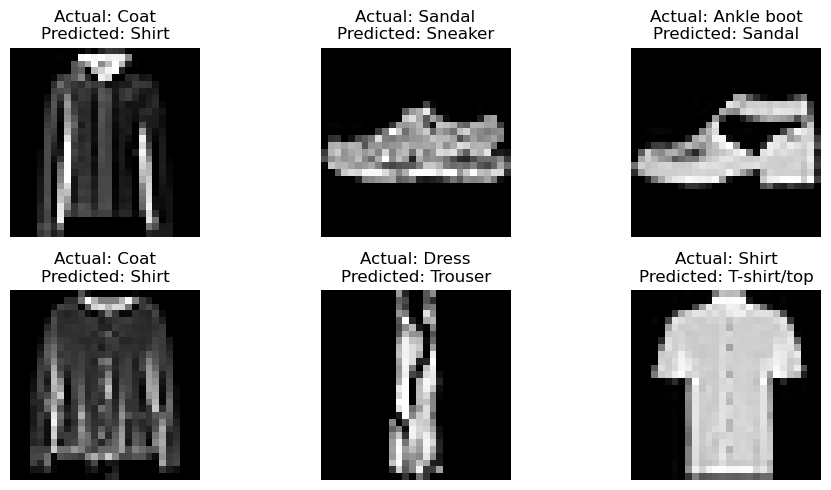

In [17]:

model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        # Find incorrect predictions
        wrong = predicted != labels

        wrong_images.extend(images[wrong].cpu())
        wrong_labels.extend(labels[wrong].cpu())
        wrong_predictions.extend(predicted[wrong].cpu())

        # Stop after collecting enough errors
        if len(wrong_images) >= 6:
            break

# Display incorrect predictions
plt.figure(figsize=(10, 5))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    plt.imshow(
        wrong_images[i].squeeze(),
        cmap="gray"
    )

    actual = class_names[wrong_labels[i]]
    predicted = class_names[wrong_predictions[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()
